In [1]:
import yfinance as yf
import pandas as pd
import requests
from bs4 import BeautifulSoup
import os
from yfinance import ticker


In [2]:
def get_sp500_tickers():
    """Fetch the list of S&P 500 tickers from Wikipedia."""
    url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'
    response = requests.get(url)
    soup = BeautifulSoup(response.text, 'html.parser')
    table = soup.find('table', {'id': 'constituents'})
    tickers = []
    for row in table.findAll('tr')[1:]:
        ticker = row.findAll('td')[0].text.strip()
        tickers.append(ticker)
    return tickers

tickers = get_sp500_tickers()

In [3]:
tickers.sort()

In [4]:

import time
def fetch_stock_data(tickers):
    all_data = {}
    print('Downloading yfinance historical price data 2000/01/01 to 2025/03/16')
    num_downloaded = 0
    for ticker in tickers:
        try:
            data = yf.download(ticker, start="2000-01-01", end="2025-03-16", progress = False, interval='1wk')
            all_data[ticker] = data
            num_downloaded +=1
            time.sleep(2.2)  # Sleep for 2 seconds between requests to avoid being blocked
        except Exception as e:
            print(f"Error downloading {ticker}: {e}")
            time.sleep(2.2)

    print('Successfully downloaded ' + str(num_downloaded/len(tickers)))
    #Save a csv for offline work
    sp500_data = pd.concat(all_data, axis=1)
    sp500_data.to_csv("sp500_data.csv")
    
    print("S&P 500 historical data saved to sp500_data.csv")
    return sp500_data
    


In [5]:
#only run on mondays
#add parameters or have it auto update to the most recent monday in the method
#price_data = fetch_stock_data(tickers)

In [23]:
price_data =pd.read_csv('sp500_data.csv')
price_data.head()

C:\Users\owenh\AppData\Local\Temp\ipykernel_26668\2757059223.py:1: DtypeWarning: Columns (1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,25

,Unnamed: 0,A,A.1,A.2,A.3,A.4,AAPL,AAPL.1,AAPL.2,AAPL.3,...,ZBRA,ZBRA.1,ZBRA.2,ZBRA.3,ZBRA.4,ZTS,ZTS.1,ZTS.2,ZTS.3,ZTS.4
0,Price,Close,High,Low,Open,Volume,Close,High,Low,Open,...,Close,High,Low,Open,Volume,Close,High,Low,Open,Volume
1,Ticker,A,A,A,A,A,AAPL,AAPL,AAPL,AAPL,...,ZBRA,ZBRA,ZBRA,ZBRA,ZBRA,ZTS,ZTS,ZTS,ZTS,ZTS
2,Date,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2000-01-01,39.165061950683594,47.56295637370222,35.022603135261114,47.44997958152855,20552138.0,0.7485783696174622,0.8463822417826177,0.7147226982429145,0.7890166138649021,...,23.51388931274414,26.0,23.0,25.93055534362793,2788200.0,NaN,NaN,NaN,NaN,NaN
4,2000-01-08,41.19864273071289,42.064794024535004,38.60018884924656,41.57522997034761,7885558.0,0.755631148815155,0.769267246196933,0.6507737009272729,0.7673865038951136,...,26.63888931274414,26.77777862548828,23.333332061767578,23.44444465637207,2562975.0,NaN,NaN,NaN,NaN,NaN


In [ ]:
price_data = price_data.T.drop(2, axis = 1)

In [ ]:
price_data.columns = price_data.iloc[0]  # Set first row as new column headers
df = price_data[1:].reset_index(drop=True)  # Drop the first row and reset index

Unnamed: 0,Price,Ticker,2000-01-01,2000-01-08,2000-01-15,2000-01-22,2000-01-24,2000-01-29,2000-01-31,2000-02-05,...,2025-02-18,2025-02-22,2025-02-24,2025-02-25,2025-03-01,2025-03-03,2025-03-04,2025-03-08,2025-03-10,2025-03-11
0,Close,A,39.165061950683594,41.19864273071289,41.42458724975586,41.010345458984375,NaN,45.94362258911133,NaN,45.41640853881836,...,NaN,127.919998,NaN,NaN,126.699997,NaN,NaN,121.18,NaN,NaN
1,High,A,47.56295637370222,42.064794024535004,43.910063962864236,43.269868695585416,NaN,46.847433549276204,NaN,49.521207204473974,...,NaN,136.940002,NaN,NaN,129.5,NaN,NaN,126.650002,NaN,NaN
2,Low,A,35.022603135261114,38.60018884924656,40.03121530411489,40.03121743779949,NaN,39.014421294398055,NaN,45.07747817451255,...,NaN,125.809998,NaN,NaN,121.449997,NaN,NaN,117.169998,NaN,NaN
3,Open,A,47.44997958152855,41.57522997034761,41.34927045521247,41.27395586059228,NaN,40.70906322973327,NaN,46.809780356580596,...,NaN,135.5,NaN,NaN,129.0,NaN,NaN,125.209999,NaN,NaN
4,Volume,A,20552138.0,7885558.0,8652921.0,6749823.0,NaN,7315035.0,NaN,5445351.0,...,NaN,12506200.0,NaN,NaN,11111600.0,NaN,NaN,12289600.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2512,Close,ZTS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,167.240005,NaN,NaN,170.369995,NaN,NaN,161.259995,NaN
2513,High,ZTS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,169.0,NaN,NaN,174.800003,NaN,NaN,177.0,NaN
2514,Low,ZTS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,160.820007,NaN,NaN,165.220001,NaN,NaN,158.300003,NaN
2515,Open,ZTS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,162.080002,NaN,NaN,166.25,NaN,NaN,169.649994,NaN


In [ ]:
df_long = df.melt(id_vars=["Price", "Ticker"], var_name="Date", value_name="Value")
df_long.to_csv('sp500_long.csv')

In [28]:
df_long.head()

,Price,Ticker,Date,Value
0,Close,A,2000-01-01,39.165061950683594
1,High,A,2000-01-01,47.56295637370222
2,Low,A,2000-01-01,35.022603135261114
3,Open,A,2000-01-01,47.44997958152855
4,Volume,A,2000-01-01,20552138.0


In [ ]:

    
    min_value = ticker_hist['Close'].min()
    max_value = ticker_hist['Close'].max()
    current_value = ticker_hist['Close'].iloc[-1]
    weight = max_value - min_value
    score = (max_value - current_value) / (current_value - min_value)
    
    return {
        "ticker": ticker,
        "min_val": min_value,
        "max_val": max_value,
        "current_value": current_value,
        "score": score,
        "weight": weight,
        "weighted_score": score / weight if weight != 0 else 0
    }




In [ ]:
df = pd.DataFrame(stock_data).sort_values(by="score")
deals = df[df["score"] >= 1]
deals.to_csv('sp500_with_scores.csv')

KeyError: 'score'

In [ ]:
import matplotlib.pyplot as plt

# Plot histogram using Pandas
deals['score'].plot(kind='hist', bins=100, alpha=0.7, color='blue', edgecolor='black')
plt.title('Histogram of Scores')
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)

# Show the plot
plt.show()

ValueError: autodetected range of [1.034445837157342, inf] is not finite

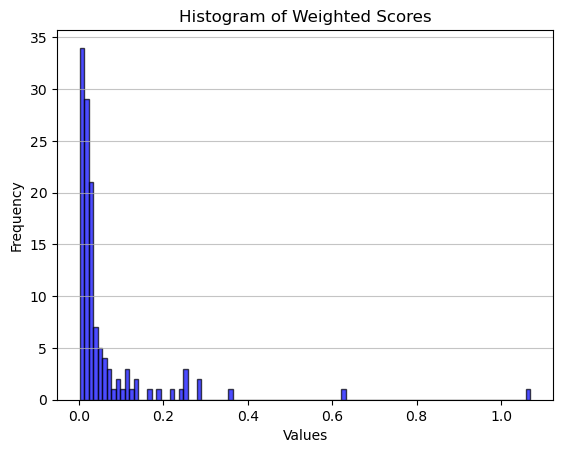

In [ ]:
# Plot histogram using Pandas
deals['weighted_score'].plot(kind='hist', bins=100, alpha=0.7, color='blue', edgecolor='black')
plt.title('Histogram of Weighted Scores')
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)

# Show the plot
plt.show()

In [ ]:
# Load the S&P 500 dataset
url = "https://datahub.io/core/s-and-p-500-companies/r/constituents.csv"  # Replace with your dataset URL or file path
df = pd.read_csv(url)

# Extract the ticker, sector, and industry columns
tickers = df['Symbol'].tolist()
sectors = df['GICS Sector'].tolist()
industries = df['GICS Sub-Industry'].tolist()

In [ ]:
#Makes a df with sector and industry information
infoFrame = pd.DataFrame({
    'ticker': tickers, 
    'sector': sectors, 
    'industry': industries})

In [ ]:
#Adds the industry and sector columns to the dataframe
merged_df = pd.merge(infoFrame, deals, on='ticker', how='inner')

In [ ]:
#Gets dividend T/F for each stock on the narrowed ticker list (long)
with_divs = []
for x in merged_df['ticker']:
    divs = yf.Ticker(x).dividends
    
    if len(divs) > 0:
        with_divs.append(x)

In [ ]:
#Adds a column that indicates if a stock has a dividend
merged_df["divs"] = merged_df['ticker'].apply(lambda x: x in with_divs)


In [ ]:
#Groups stocks with a dividend by sector
grouped_sectors = {sector: group for sector, group in merged_df[merged_df['divs'] == True].groupby('sector')}

#Groups stocks with no dividend by sector
grouped_nDivs = {sector: group for sector, group in merged_df[merged_df['divs'] == False].groupby('sector')}



In [ ]:
#Prints data on stocks with dividends
for sector, group in grouped_sectors.items():
    print(f"Sector: {sector}")
    print(group.drop(columns = ['sector','weight', 'weighted_score', 'divs']).sort_values(by="score" ,ascending=False))
    print()

Sector: Communication Services
    ticker                      industry    min_val     max_val  \
81    PARA        Movies & Entertainment   9.521918   90.812828   
71    MTCH  Interactive Media & Services  28.284594  174.509476   
102    DIS        Movies & Entertainment  78.352066  199.446106   
29   CMCSA             Cable & Satellite  26.823023   56.013733   

     current_value      score  
81       11.300000  44.718316  
71       34.689999  21.828358  
102     110.379997   2.780889  
29       35.389999   2.407353  

Sector: Consumer Discretionary
    ticker                             industry     min_val     max_val  \
78     NKE  Apparel, Accessories & Luxury Goods   59.454521  170.152161   
9     APTV         Automotive Parts & Equipment   33.549999  178.119995   
51       F             Automobile Manufacturers    3.268043   20.632551   
67     LVS                     Casinos & Gaming   29.224714   65.691078   
56     HAS                     Leisure Products   37.083851   91.0

In [ ]:
#Prints data on stocks without dividends
for sector, group in grouped_nDivs.items():
    print(f"Sector: {sector}")
    print(group.drop(columns = ['sector','weight', 'weighted_score', 'divs']).sort_values(by="score" ,ascending=False))
    print()

Sector: Communication Services
    ticker           industry     min_val     max_val  current_value  \
103    WBD       Broadcasting    6.710000   77.269997      10.340000   
27    CHTR  Cable & Satellite  254.610001  821.010010     360.269989   

         score  
103  18.438015  
27    4.360591  

Sector: Consumer Discretionary
   ticker                        industry  min_val     max_val  current_value  \
21    CZR                Casinos & Gaming     7.10  119.489998      39.759998   
75    MHK                Home Furnishings    58.66  229.740005     121.010002   
23    KMX               Automotive Retail    44.27  154.850006      88.900002   
79   NCLH  Hotels, Resorts & Cruise Lines     7.77   52.020000      26.379999   

       score  
21  2.441213  
75  1.743865  
23  1.477706  
79  1.377754  

Sector: Consumer Staples
   ticker                             industry    min_val     max_val  \
39   DLTR  Consumer Staples Merchandise Retail  61.209999  174.080002   

    current_val

In [ ]:
merged_df.to_csv('stock_and_info.csv')

In [ ]:
merged_df

,ticker,sector,industry,min_val,max_val,current_value,score,weight,weighted_score,divs
0,ADBE,Information Technology,Application Software,275.200012,688.369995,460.160004,1.233834,413.169983,0.002986,True
1,AMD,Information Technology,Semiconductors,38.709999,211.380005,113.099998,1.321145,172.670006,0.007651,False
2,AES,Utilities,Independent Power Producers & Energy Traders,8.089493,26.797682,9.930000,9.164690,18.708189,0.489876,True
3,ALB,Materials,Specialty Chemicals,48.421322,317.137085,81.209999,7.195383,268.715763,0.026777,True
4,ARE,Real Estate,Office REITs,86.687798,197.903793,94.849998,12.625736,111.215996,0.113524,True
...,...,...,...,...,...,...,...,...,...,...
104,WST,Health Care,Health Care Supplies,127.436783,467.692017,214.729996,2.897843,340.255234,0.008517,True
105,WYNN,Consumer Discretionary,Casinos & Gaming,42.221642,137.401886,88.820000,1.042566,95.180244,0.010954,True
106,ZBRA,Information Technology,Electronic Equipment & Instruments,161.509995,614.549988,318.359985,1.888365,453.039993,0.004168,False
107,ZBH,Health Care,Health Care Equipment,75.286736,168.359055,100.519997,2.688478,93.072319,0.028886,True
